In [3]:
import os
import json
import pandas as pd 

In [4]:
# ===========================================
#  MODULE 1: EDA &  Catalog Understanding
# ===========================================
json_folder = r"C:\Projects\Final Project\Data\json_products"

# Check if folder exists
if not os.path.exists(json_folder):
    print("JSON folder not found!")
else:
    print("JSON folder found successfully!")

# Count total JSON files
json_files = [file for file in os.listdir(json_folder) if file.endswith(".json")]

print("Total JSON files available:", len(json_files))
print("First 5 JSON files:", json_files[:5])

JSON folder found successfully!
Total JSON files available: 44446
First 5 JSON files: ['10000.json', '10001.json', '10002.json', '10003.json', '10004.json']


In [5]:
# JSON Flattening
all_rows = []

for file in json_files:

    file_path = os.path.join(json_folder, file)

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            content = json.load(f)

        product = content.get("data", {})

        row = {
            "id": product.get("id"),
            "productDisplayName": product.get("productDisplayName"),
            "brandName": product.get("brandName"),
            "gender": product.get("gender"),
            "baseColour": product.get("baseColour"),
            "season": product.get("season"),
            "year": product.get("year"),
            "usage": product.get("usage"),
            "articleType": product.get("articleType", {}).get("typeName"),
            "masterCategory": product.get("masterCategory", {}).get("typeName"),
            "subCategory": product.get("subCategory", {}).get("typeName"),
            "imageURL": product.get("styleImages", {}).get("default", {}).get("imageURL")
        }

        all_rows.append(row)

    except Exception as e:
        continue

print("JSON Flattening completed.")

JSON Flattening completed.


In [6]:
# Convert into Data Frame
df = pd.DataFrame(all_rows)

print("Raw Dataset Shape:", df.shape)
df.head()


Raw Dataset Shape: (44446, 12)


,id,productDisplayName,brandName,gender,baseColour,season,year,usage,articleType,masterCategory,subCategory,imageURL
0,10000,Palm Tree Girls Sp Jace Sko White Skirts,Palm Tree,Women,White,Summer,2011,Casual,Skirts,Apparel,Bottomwear,http://assets.myntassets.com/v1/images/style/p...
1,10001,Palm Tree Kids Girls Sp Jema Skt Blue Skirts,Palm Tree,Women,Blue,Summer,2011,Casual,Skirts,Apparel,Bottomwear,http://assets.myntassets.com/v1/images/style/p...
2,10002,Palm Tree Kids Sp Jema Skt Blue Skirts,Palm Tree,Women,Blue,Summer,2011,Casual,Skirts,Apparel,Bottomwear,http://assets.myntassets.com/v1/images/style/p...
3,10003,Nike Women As Nike Eleme White T-Shirt,Nike,Women,White,Fall,2011,Sports,Tshirts,Apparel,Topwear,http://assets.myntassets.com/v1/images/style/p...
4,10004,Nike Men As 7 Sw Temp Grey Shorts,Nike,Men,Grey,Fall,2011,Sports,Shorts,Apparel,Bottomwear,http://assets.myntassets.com/v1/images/style/p...


In [7]:
# Save CSV
raw_csv_path = r"C:\Projects\Final Project\Data\fashion_products.csv"

df.to_csv(raw_csv_path, index=False)

print("Raw CSV saved successfully at:")
print(raw_csv_path)


Raw CSV saved successfully at:
C:\Projects\Final Project\Data\fashion_products.csv


In [8]:
# Data Cleaning 
df.isnull().sum()

id                    0
productDisplayName    0
brandName             0
gender                0
baseColour            0
season                0
year                  0
usage                 0
articleType           0
masterCategory        0
subCategory           0
imageURL              5
dtype: int64

In [9]:
# Data Cleaning

# Remove rows missing critical fields
df = df.dropna(subset=["id", "gender", "articleType", "imageURL"])

# Standardize gender (prevents filtering mistakes later)
df["gender"] = df["gender"].str.strip().str.lower()

# Standardize masterCategory
df["masterCategory"] = df["masterCategory"].str.strip()

# Fill missing season values
df["season"] = df["season"].fillna("Unknown")
df["season"] = df["season"].replace("", "Unknown")

# Remove duplicate image URLs (prevents image mixing)
df = df.drop_duplicates(subset=["imageURL"])

print("After Cleaning Shape:", df.shape)
print("\nNull Values:\n")
print(df.isnull().sum())

After Cleaning Shape: (44439, 12)

Null Values:

id                    0
productDisplayName    0
brandName             0
gender                0
baseColour            0
season                0
year                  0
usage                 0
articleType           0
masterCategory        0
subCategory           0
imageURL              0
dtype: int64


In [10]:
print("Total Products:", len(df))


Total Products: 44439


In [11]:
# Save cleaned DataSet
clean_csv_path = r"C:\Projects\Final Project\Data\fashion_products_clean.csv"

df.to_csv(clean_csv_path, index=False)

print("Clean CSV saved at:", clean_csv_path)


Clean CSV saved at: C:\Projects\Final Project\Data\fashion_products_clean.csv


In [1]:
# ==============================
#  Exploratory Data Analysis 
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns


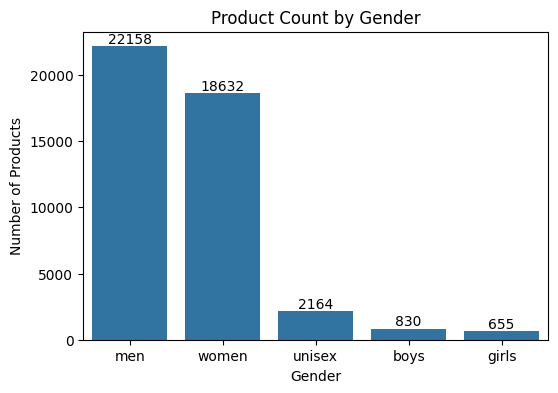

In [12]:
# 1. Product count by gender
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="gender",
                   order=df["gender"].value_counts().index)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Product Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Products")
plt.show()


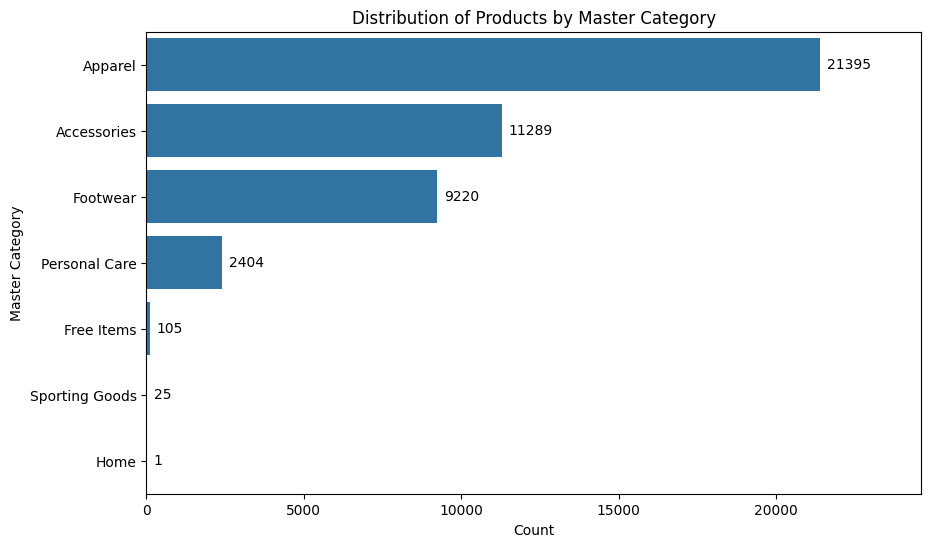

In [13]:
# 2. Distribution of masterCategory and articleType
# Distribution of Master Category
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    y="masterCategory",
    order=df["masterCategory"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, padding=5)

# Add extra space at end of x-axis
plt.xlim(0, df["masterCategory"].value_counts().max() * 1.15)

plt.title("Distribution of Products by Master Category")
plt.xlabel("Count")
plt.ylabel("Master Category")

plt.show()


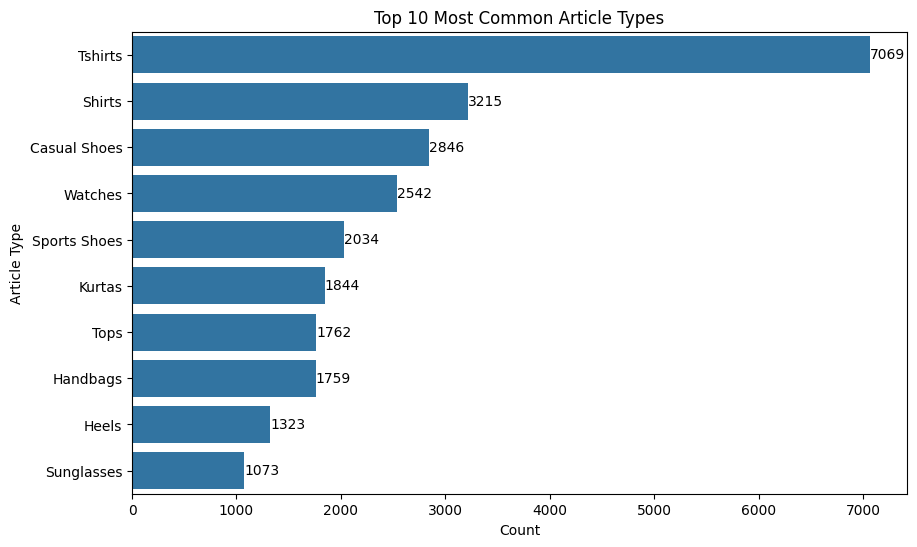

In [14]:
# Distribution of Article Type
plt.figure(figsize=(10,6))

top_articles = df["articleType"].value_counts().head(10)

ax = sns.countplot(data=df, y="articleType",
                   order=top_articles.index)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Most Common Article Types")
plt.xlabel("Count")
plt.ylabel("Article Type")
plt.show()


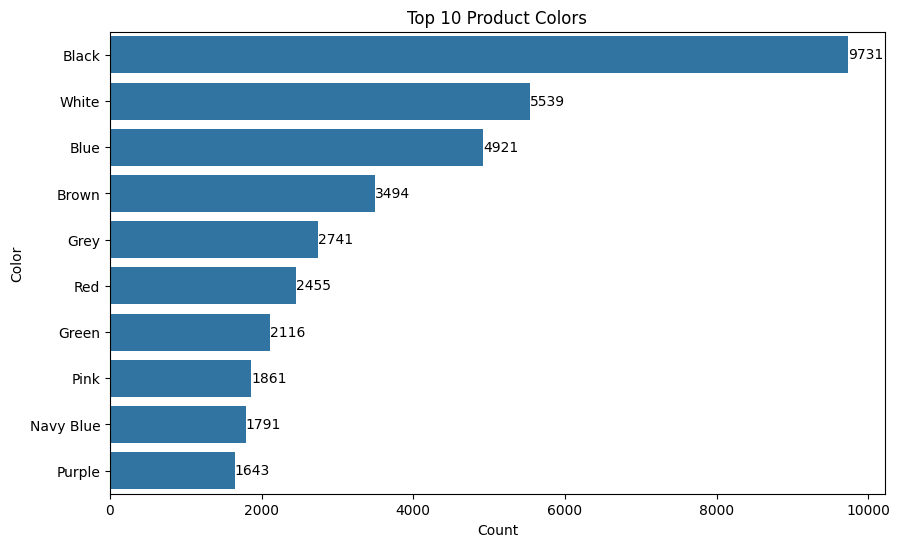

In [15]:
# 3. Color Distribution Across Categories
plt.figure(figsize=(10,6))

top_colors = df["baseColour"].value_counts().head(10)

ax = sns.countplot(data=df, y="baseColour",
                   order=top_colors.index)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Product Colors")
plt.xlabel("Count")
plt.ylabel("Color")
plt.show()


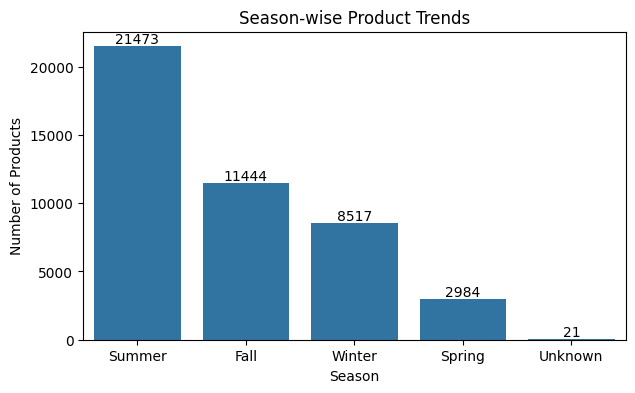

In [16]:
# 4. Seasonal product trends
plt.figure(figsize=(7,4))

ax = sns.countplot(data=df, x="season",
                   order=df["season"].value_counts().index)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Season-wise Product Trends")
plt.xlabel("Season")
plt.ylabel("Number of Products")
plt.show()


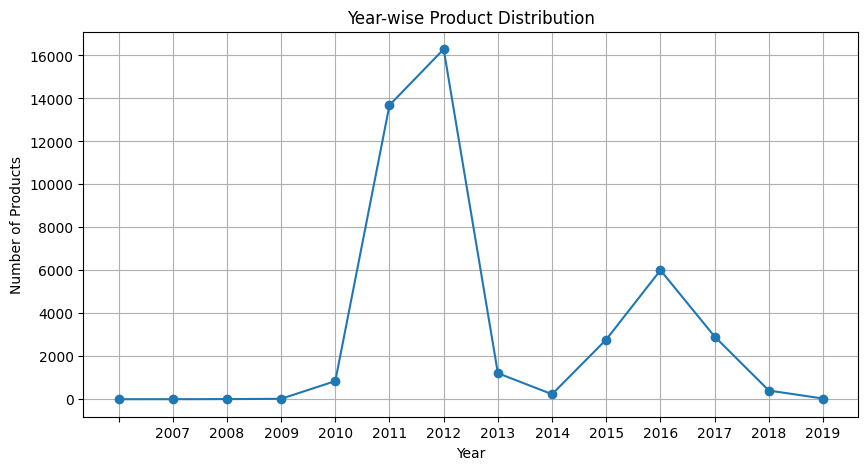

In [17]:
# 5. Year-wise product distribution
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker="o")

plt.title("Year-wise Product Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Products")
plt.grid(True)

plt.show()


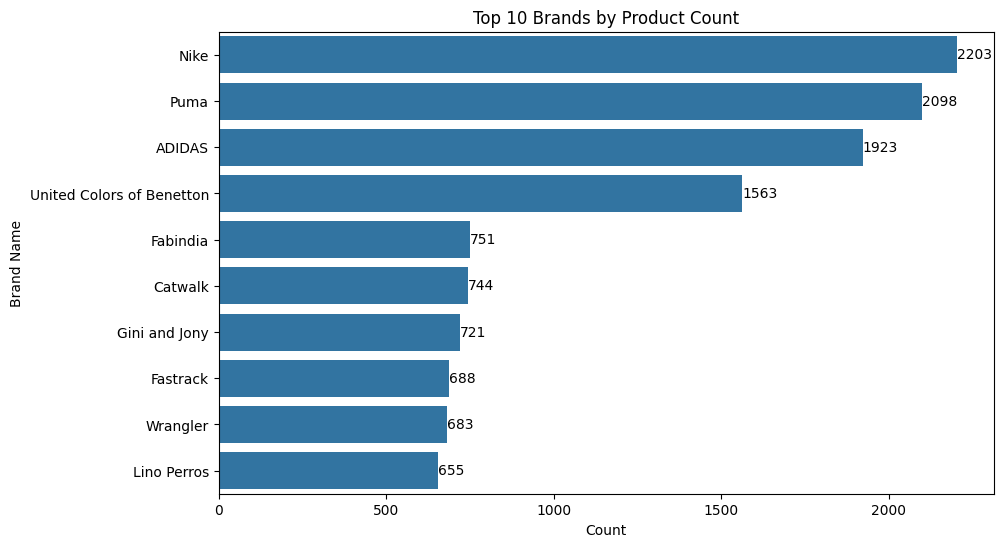

In [18]:
# 6. Brand-wise product counts
plt.figure(figsize=(10,6))

top_brands = df["brandName"].value_counts().head(10)

ax = sns.countplot(data=df, y="brandName",
                   order=top_brands.index)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Brands by Product Count")
plt.xlabel("Count")
plt.ylabel("Brand Name")
plt.show()


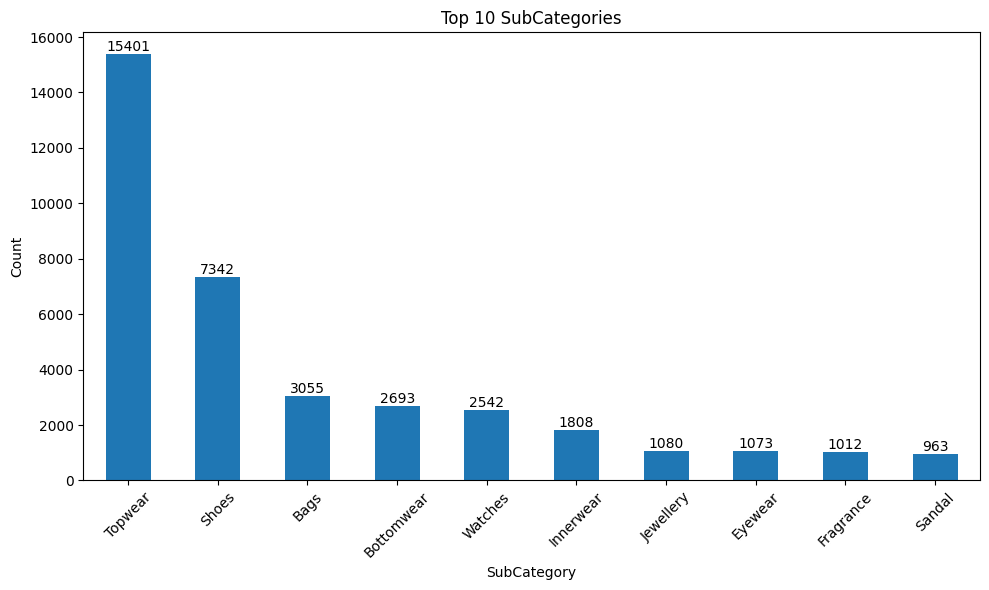

In [19]:
# 7. Top 10 SubCategories
plt.figure(figsize=(10,6))

ax = df["subCategory"].value_counts().head(10).plot(kind="bar")

# Add count labels on top of bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,   # X position
        bar.get_height(),                  # Y position
        int(bar.get_height()),             # Label text
        ha="center", va="bottom", fontsize=10
    )

plt.title("Top 10 SubCategories")
plt.xlabel("SubCategory")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

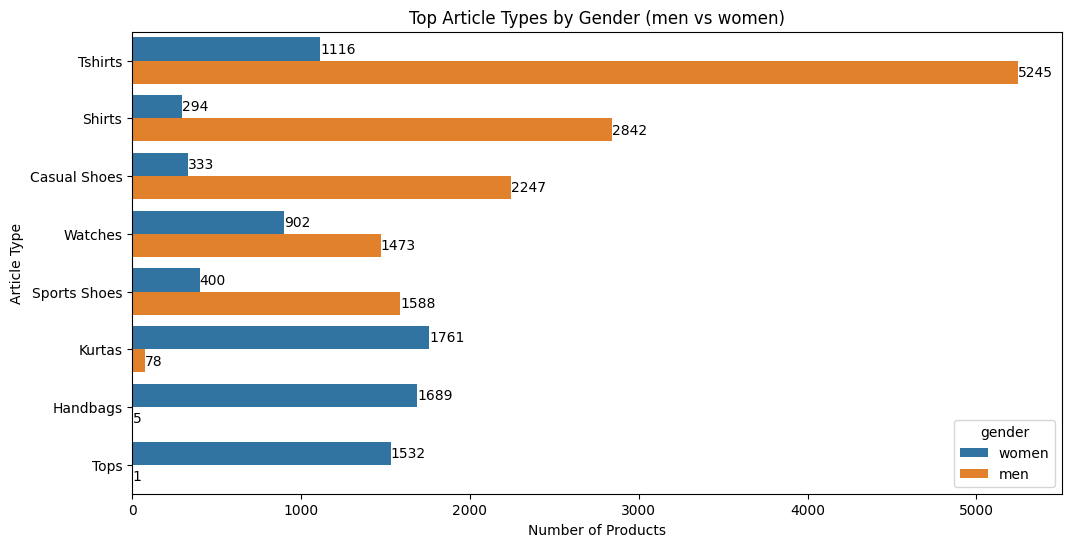

In [20]:
# 8. ArticleType by Gender (only Men and Women)
plt.figure(figsize=(12,6))

# Select only Men and Women
df_mw = df[df["gender"].isin(["men", "women"])]

# Top 8 Article Types
top_articles = df_mw["articleType"].value_counts().head(8).index

# Plot
ax = sns.countplot(
    data=df_mw[df_mw["articleType"].isin(top_articles)],
    y="articleType",
    hue="gender",
    order=top_articles
)

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top Article Types by Gender (men vs women)")
plt.xlabel("Number of Products")
plt.ylabel("Article Type")
plt.show()

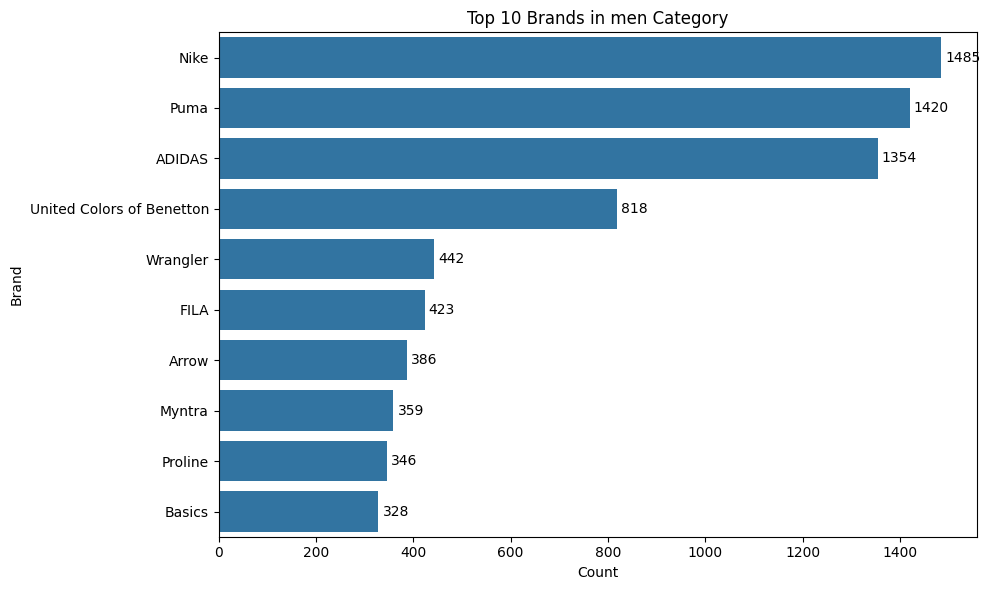

In [21]:
# 9. Top Brands in Men Category
df_men = df[df["gender"] == "men"]

top_men_brands = df_men["brandName"].value_counts().head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(x=top_men_brands.values, y=top_men_brands.index)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Top 10 Brands in men Category")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


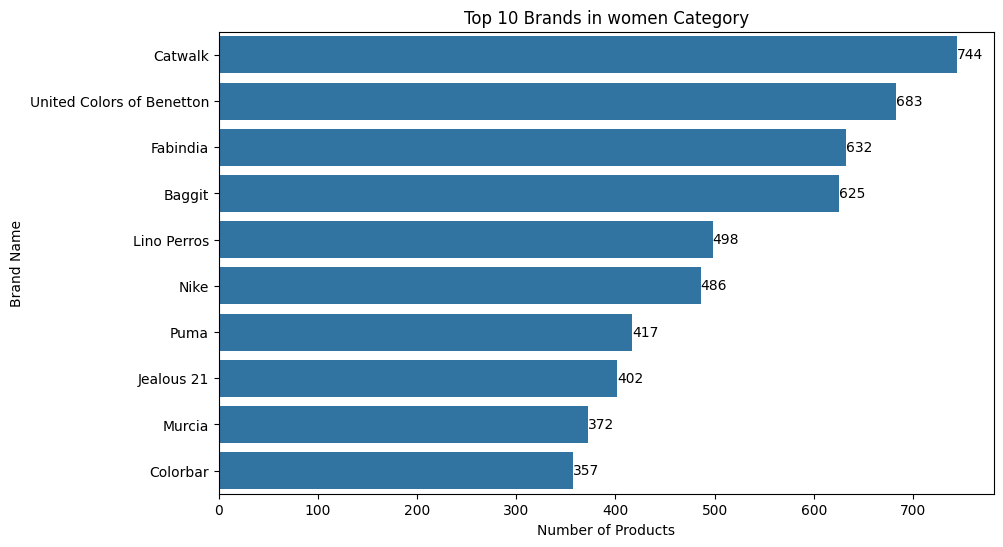

In [22]:
# 10. Top Brands in Women Category
# Filter only Women products
women_df = df[df["gender"] == "women"]

# Get Top 10 brands
top_women_brands = women_df["brandName"].value_counts().head(10).index

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=women_df,
    y="brandName",
    order=top_women_brands
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Brands in women Category")
plt.xlabel("Number of Products")
plt.ylabel("Brand Name")
plt.show()

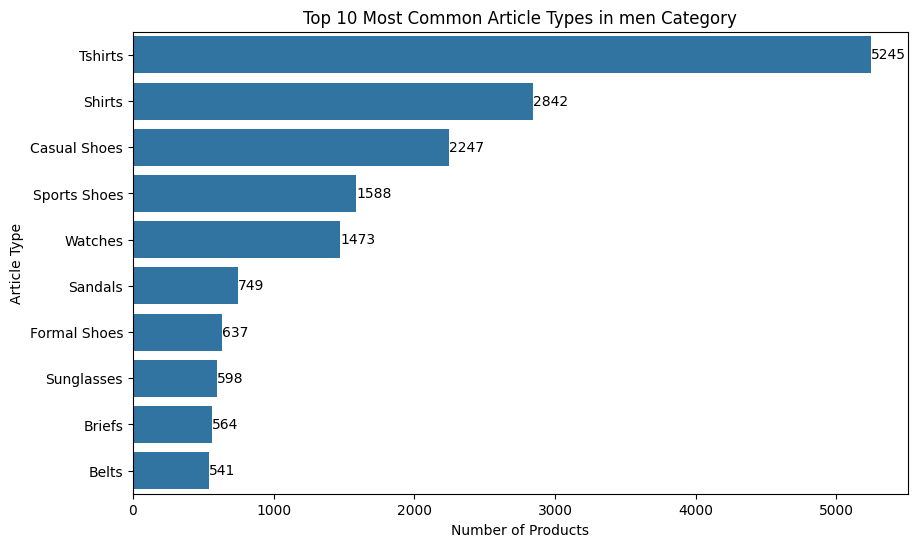

In [23]:
# 11. Most Common Article Types in Men Category
# Filter only Men products
men_df = df[df["gender"] == "men"]

# Top 10 article types in Men category
top_men_articles = men_df["articleType"].value_counts().head(10).index

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=men_df,
    y="articleType",
    order=top_men_articles
)

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Most Common Article Types in men Category")
plt.xlabel("Number of Products")
plt.ylabel("Article Type")
plt.show()


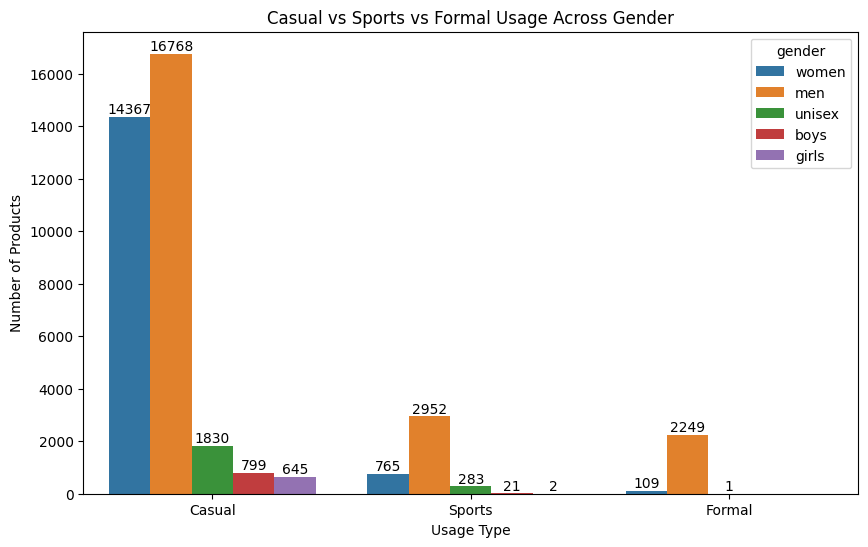

In [24]:
# 12. Casual vs Sports vs Formal usage across gender 
plt.figure(figsize=(10,6))

# Keep only top usage categories (Casual, Sports, Formal)
usage_filter = ["Casual", "Sports", "Formal"]

df_usage = df[df["usage"].isin(usage_filter)]

ax = sns.countplot(
    data=df_usage,
    x="usage",
    hue="gender",
    order=usage_filter
)

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Casual vs Sports vs Formal Usage Across Gender")
plt.xlabel("Usage Type")
plt.ylabel("Number of Products")
plt.show()


In [25]:
# ===========================================
# STRICT MEN DATASET CREATION
# ===========================================
# LOAD CLEAN DATASET

DATA_PATH = r"C:\Projects\Final Project\Data"
df = pd.read_csv(os.path.join(DATA_PATH, "fashion_products_clean.csv"))

print("Full Dataset Shape:", df.shape)


# STANDARDIZE GENDER COLUMN

df["gender"] = df["gender"].str.strip().str.lower()

print("\nAvailable Gender Categories:")
print(df["gender"].value_counts())


# SELECT CATEGORY BASED ON EDA

# Choose ONLY ONE: 'men', 'women', 'boys', 'girls'
category = "men"

df_category = df[df["gender"] == category].copy()

print("\nCategory Selected:", category.upper())
print("Filtered Dataset Shape:", df_category.shape)

print("\nGender Check:")
print(df_category["gender"].value_counts())


# QUICK EDA INSIGHTS (For Documentation)

print("\nTop 5 Brands:")
print(df_category["brandName"].value_counts().head(5))

print("\nTop 5 Article Types:")
print(df_category["articleType"].value_counts().head(5))

print("\nNumber of Unique Colors:",
      df_category["baseColour"].nunique())

if "season" in df_category.columns:
    print("\nProduct Counts by Season:")
    print(df_category["season"].value_counts())


# SELECT TOP 10 ARTICLE TYPES

top_classes = df_category["articleType"].value_counts().head(10).index

df_category = df_category[
    df_category["articleType"].isin(top_classes)
].copy()

print("\nTop 10 Article Types Selected:")
print(df_category["articleType"].value_counts())
print("Final Dataset Shape:", df_category.shape)

Full Dataset Shape: (44439, 12)

Available Gender Categories:
gender
men       22158
women     18632
unisex     2164
boys        830
girls       655
Name: count, dtype: int64

Category Selected: MEN
Filtered Dataset Shape: (22158, 12)

Gender Check:
gender
men    22158
Name: count, dtype: int64

Top 5 Brands:
brandName
Nike                         1485
Puma                         1420
ADIDAS                       1354
United Colors of Benetton     818
Wrangler                      442
Name: count, dtype: int64

Top 5 Article Types:
articleType
Tshirts         5245
Shirts          2842
Casual Shoes    2247
Sports Shoes    1588
Watches         1473
Name: count, dtype: int64

Number of Unique Colors: 40

Product Counts by Season:
season
Summer     10874
Fall        7086
Winter      3225
Spring       965
Unknown        8
Name: count, dtype: int64

Top 10 Article Types Selected:
articleType
Tshirts         5245
Shirts          2842
Casual Shoes    2247
Sports Shoes    1588
Watches         

In [26]:
# Save Selected Category Dataset
output_path = os.path.join(DATA_PATH, "men_products.csv")
df_category.to_csv(output_path, index=False)

print("\nmen_products.csv saved successfully!")
print("Saved at:", output_path)


men_products.csv saved successfully!
Saved at: C:\Projects\Final Project\Data\men_products.csv


In [27]:
# ============================================================================
# MODULE 2: Image Classification & Similarity-Based Recommendation System
# ============================================================================
# Part 1: Image Dataset Preparation
# Load strict Men dataset
DATA_PATH = r"C:\Projects\Final Project\Data"
df = pd.read_csv(os.path.join(DATA_PATH, "men_products.csv"))

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["articleType"].value_counts())

Dataset Shape: (16484, 12)

Class Distribution:
articleType
Tshirts         5245
Shirts          2842
Casual Shoes    2247
Sports Shoes    1588
Watches         1473
Sandals          749
Formal Shoes     637
Sunglasses       598
Briefs           564
Belts            541
Name: count, dtype: int64


In [28]:
# 2: Create Dataset Folder Structure
import shutil
base_dir = "dataset_men"

for label in df["articleType"].unique():
    folder_path = os.path.join(base_dir, label)
    os.makedirs(folder_path, exist_ok=True)

print("\nFolders created successfully!")



Folders created successfully!


In [30]:
# Download Images using Image URLs
import requests
from tqdm import tqdm
import os
print("\nStarting image download...\n")

success_count = 0
fail_count = 0

for _, row in tqdm(df.iterrows(), total=len(df)):

    url = row["imageURL"]
    label = row["articleType"]
    product_id = row["id"]

    # Skip if URL missing
    if pd.isna(url):
        fail_count += 1
        continue

    save_path = os.path.join(base_dir, label, f"{product_id}.jpg")

    # Skip if already downloaded
    if os.path.exists(save_path):
        continue

    try:
        response = requests.get(url, timeout=5)

        if response.status_code == 200 and response.content:
            with open(save_path, "wb") as f:
                f.write(response.content)
            success_count += 1
        else:
            fail_count += 1

    except Exception:
        fail_count += 1
        continue

print("\nDownload Completed!")
print("Successfully downloaded:", success_count)
print("Failed downloads:", fail_count)


Starting image download...



100%|██████████| 16484/16484 [46:22<00:00,  5.92it/s]   


Download Completed!
Successfully downloaded: 16482
Failed downloads: 2


In [31]:
# Verify Download Count
print("\nFinal Image Count Per Class:\n")

total_images = 0

for label in os.listdir(base_dir):
    folder = os.path.join(base_dir, label)

    # Ensure it is a directory (skip unwanted files)
    if os.path.isdir(folder):

        # Count only image files
        image_count = len([
            file for file in os.listdir(folder)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        total_images += image_count
        print(f"{label}: {image_count} images")

print("\nTotal Images in Dataset:", total_images)
print("\nDataset Ready for Training!")



Final Image Count Per Class:

Belts: 541 images
Briefs: 564 images
Casual Shoes: 2247 images
Formal Shoes: 637 images
Sandals: 749 images
Shirts: 2841 images
Sports Shoes: 1587 images
Sunglasses: 598 images
Tshirts: 5245 images
Watches: 1473 images

Total Images in Dataset: 16482

Dataset Ready for Training!


In [41]:
#  FINAL DATASET VALIDATION
import os
import pandas as pd
from PIL import Image

DATA_PATH = r"C:\Projects\Final Project\Data"
CSV_PATH = os.path.join(DATA_PATH, "men_products.csv")
BASE_DIR = "dataset_men"

# Remove Corrupt Images

print("Checking for corrupt images...\n")

corrupt_count = 0
valid_ids = []

for label in os.listdir(BASE_DIR):
    folder = os.path.join(BASE_DIR, label)

    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith(".jpg"):
                file_path = os.path.join(folder, file)

                try:
                    img = Image.open(file_path)
                    img.verify()  # check corruption
                    valid_ids.append(int(file.replace(".jpg", "")))

                except:
                    os.remove(file_path)
                    corrupt_count += 1

print("Corrupt images removed:", corrupt_count)

# Sync CSV with Existing Images

df = pd.read_csv(CSV_PATH)

df = df[df["id"].isin(valid_ids)].copy()

df.to_csv(CSV_PATH, index=False)

print("\nCSV synced successfully!")
print("Updated Dataset Shape:", df.shape)

# Final Image Count Per Class

print("\nFinal Image Count Per Class:\n")

for label in os.listdir(BASE_DIR):
    folder = os.path.join(BASE_DIR, label)
    if os.path.isdir(folder):
        print(label, ":", len(os.listdir(folder)))

print("\nDataset is clean and ready for training!")

Checking for corrupt images...

Corrupt images removed: 0

CSV synced successfully!
Updated Dataset Shape: (15726, 12)

Final Image Count Per Class:

Belts : 538
Briefs : 564
Casual Shoes : 1895
Formal Shoes : 633
Sandals : 748
Shirts : 2679
Sports Shoes : 1495
Sunglasses : 598
Tshirts : 5121
Watches : 1455

Dataset is clean and ready for training!


In [42]:
# Image Classification Model Development
# Load Dataset
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import pickle

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_INITIAL = 10
EPOCHS_FINE = 5
base_dir = "dataset_men"   

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_data.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# Save class names
with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

print("Class names saved successfully!")

Found 15726 files belonging to 10 classes.
Using 12581 files for training.
Found 15726 files belonging to 10 classes.
Using 3145 files for validation.
Classes: ['Belts', 'Briefs', 'Casual Shoes', 'Formal Shoes', 'Sandals', 'Shirts', 'Sports Shoes', 'Sunglasses', 'Tshirts', 'Watches']
Number of classes: 10
Class names saved successfully!


In [43]:
# NORMALIZATION + PERFORMANCE OPTIMIZATION
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)

print("Normalization and Prefetching Applied!")


Normalization and Prefetching Applied!


In [44]:
# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [45]:
# Load Pretrained Model (Transfer Learning) and Freeze base layers (MANDATORY)
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze initially

In [47]:
# Add Custom Classification Head
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [48]:
# Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [49]:
# Train Model
# CallBacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Initial Traing

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_INITIAL,
    callbacks=[early_stop]
)

# Fine-Tuning Unfreeze entire base model
base_model.trainable = True

# Freeze first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FINE,
    callbacks=[early_stop]
)

Epoch 1/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 1392s 4s/step - accuracy: 0.8979 - loss: 0.2734 - val_accuracy: 0.9332 - val_loss: 0.1635
Epoch 2/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 2293s 6s/step - accuracy: 0.9367 - loss: 0.1677 - val_accuracy: 0.9453 - val_loss: 0.1395
Epoch 3/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 0.9423 - loss: 0.1514 - val_accuracy: 0.9482 - val_loss: 0.1310
Epoch 4/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.9454 - loss: 0.1398 - val_accuracy: 0.9574 - val_loss: 0.1135
Epoch 5/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.9500 - loss: 0.1327 - val_accuracy: 0.9520 - val_loss: 0.1200
Epoch 6/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 463s 1s/step - accuracy: 0.9538 - loss: 0.1225 - val_accuracy: 0.9526 - val_loss: 0.1227
Epoch 7/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.9553 - loss: 0.1179 - val_accuracy: 0.9583 - val_loss: 0.1113
Epoch 8/10
394/394 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - accuracy: 0.9581 - loss: 0.1126 - val_ac

In [50]:
# Confusion Matrix and Precision & Recall
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 892ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 941ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step
1/1 ━━━

In [51]:
# Save the Module
model.save("men_fashion_classifier.keras")
print("Model saved successfully!")

Model saved successfully!


In [52]:
# Test Load Model
from tensorflow.keras.models import load_model
loaded_model = tf.keras.models.load_model("men_fashion_classifier.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [53]:
# Part-B Similarity-Based Recommendation System
# Image Embedding Extraction
# Load Your Trained Model 
import os
import numpy as np
import pickle
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from sklearn.metrics.pairwise import cosine_similarity

MODEL_PATH = "men_fashion_classifier.keras"

model = load_model(MODEL_PATH)
print("Model loaded successfully!")

# Remove final softmax layer
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

print("Feature extractor ready!")


Model loaded successfully!
Feature extractor ready!


In [54]:
# Load Image Dataset (No shuffle) 

DATASET_PATH = "dataset_men"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False   # MUST be False
)

# Normalize exactly like training

image_paths = dataset.file_paths

dataset = dataset.map(lambda x, y: (x / 255.0, y))

print("Total images:", len(image_paths))

Found 15726 files belonging to 10 classes.
Total images: 15726


In [55]:
# Extract Embedding 
embeddings = []

for images, _ in dataset:
    features = feature_extractor.predict(images, verbose=0)
    embeddings.append(features)

embeddings = np.vstack(embeddings)

# Normalize embeddings (IMPORTANT for cosine similarity)
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print("Embedding shape:", embeddings.shape)

Embedding shape: (15726, 128)


In [56]:
# Safety Check 
if embeddings.shape[0] != len(image_paths):
    raise ValueError("Mismatch between embeddings and image paths!")

print("Embeddings and images count match ✅")

Embeddings and images count match ✅


In [57]:
# Save Embeddings and Paths

np.save("men_embeddings.npy", embeddings)

with open("image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)

print("Embeddings and image paths saved successfully!")

Embeddings and image paths saved successfully!


In [58]:
# ==========================================================
# SIMILARITY ENGINE
# ==========================================================

# Load Saved Data

embeddings = np.load("men_embeddings.npy")

with open("image_paths.pkl", "rb") as f:
    image_paths = pickle.load(f)

print("Loaded embeddings:", embeddings.shape)
print("Loaded image paths:", len(image_paths))


Loaded embeddings: (15726, 128)
Loaded image paths: 15726


In [59]:
# Recommend Similar Images
def recommend_similar(image_index, top_n=5):

    if image_index >= len(embeddings):
        raise IndexError("Invalid image index!")

    query_embedding = embeddings[image_index].reshape(1, -1)

    similarities = cosine_similarity(query_embedding, embeddings)[0]

    sorted_indices = np.argsort(similarities)[::-1]

    # Remove the query image itself
    similar_indices = sorted_indices[1:top_n+1]

    return similar_indices

In [60]:
# Map To Metadata 

# Load metadata CSV
df = pd.read_csv(r"C:\Projects\Final Project\Data\men_products.csv")

def get_similar_products(image_index, top_n=5):

    indices = recommend_similar(image_index, top_n)
    results = []

    for i in indices:
        image_path = image_paths[i]

        # Extract product ID safely
        image_id = int(os.path.splitext(os.path.basename(image_path))[0])

        product_row = df[df["id"] == image_id]

        if product_row.empty:
            continue

        row = product_row.iloc[0]

        results.append({
            "image_path": image_path,
            "articleType": row["articleType"],
            "brandName": row["brandName"],
            "color": row["baseColour"],
            "season": row["season"]
        })

    return results

In [61]:
# TEST
results = get_similar_products(10, top_n=10)

for item in results:
    print(item)

{'image_path': 'dataset_men\\Belts\\32615.jpg', 'articleType': 'Belts', 'brandName': 'Levitate', 'color': 'Black', 'season': 'Spring'}
{'image_path': 'dataset_men\\Belts\\18829.jpg', 'articleType': 'Belts', 'brandName': 'Peter England', 'color': 'Tan', 'season': 'Summer'}
{'image_path': 'dataset_men\\Belts\\37449.jpg', 'articleType': 'Belts', 'brandName': 'Turtle', 'color': 'Brown', 'season': 'Summer'}
{'image_path': 'dataset_men\\Belts\\18831.jpg', 'articleType': 'Belts', 'brandName': 'Peter England', 'color': 'Brown', 'season': 'Summer'}
{'image_path': 'dataset_men\\Belts\\14977.jpg', 'articleType': 'Belts', 'brandName': 'New Hide', 'color': 'Black', 'season': 'Fall'}
{'image_path': 'dataset_men\\Belts\\18603.jpg', 'articleType': 'Belts', 'brandName': 'New Hide', 'color': 'Black', 'season': 'Fall'}
{'image_path': 'dataset_men\\Belts\\36028.jpg', 'articleType': 'Belts', 'brandName': 'OTLS', 'color': 'Brown', 'season': 'Summer'}
{'image_path': 'dataset_men\\Belts\\37995.jpg', 'articleT